In [1]:
import pandas as pd
import numpy as np

# 设置随机种子
np.random.seed(42)

# 模拟用户ID
user_ids = np.random.randint(1000, 1100, 1000)

# 行为类型
behaviors = np.random.choice(['view', 'click', 'cart', 'buy'], 1000, p=[0.5, 0.3, 0.15, 0.05])

# 时间
dates = pd.date_range(start='2025-01-01', periods=30)
times = np.random.choice(dates, 1000)

# 构建数据集
df = pd.DataFrame({
    'user_id': user_ids,
    'behavior': behaviors,
    'time': times
})

# 保存数据（可选）
df.to_csv('ecommerce_data.csv', index=False)

df.head()

,user_id,behavior,time
0,1051,click,2025-01-18
1,1092,click,2025-01-13
2,1014,view,2025-01-02
3,1071,view,2025-01-09
4,1060,view,2025-01-21


In [2]:
# 查看基本信息
print(df.info())
print(df.isnull().sum())

# 去重
df = df.drop_duplicates()

# 转换时间格式
df['time'] = pd.to_datetime(df['time'])

# 提取日期
df['date'] = df['time'].dt.date

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   1000 non-null   int32         
 1   behavior  1000 non-null   object        
 2   time      1000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int32(1), object(1)
memory usage: 19.7+ KB
None
user_id     0
behavior    0
time        0
dtype: int64


In [3]:
# 统计每个阶段的用户数（去重）
view_users = df[df['behavior'] == 'view']['user_id'].nunique()
click_users = df[df['behavior'] == 'click']['user_id'].nunique()
cart_users = df[df['behavior'] == 'cart']['user_id'].nunique()
buy_users = df[df['behavior'] == 'buy']['user_id'].nunique()

# 计算转化率
click_rate = click_users / view_users
cart_rate = cart_users / click_users
buy_rate = buy_users / cart_users

print("浏览用户数:", view_users)
print("点击用户数:", click_users)
print("加购用户数:", cart_users)
print("购买用户数:", buy_users)

print("\n转化率：")
print("点击率:", round(click_rate, 2))
print("加购率:", round(cart_rate, 2))
print("购买率:", round(buy_rate, 2))

浏览用户数: 100
点击用户数: 95
加购用户数: 79
购买用户数: 38

转化率：
点击率: 0.95
加购率: 0.83
购买率: 0.48


In [4]:
# 每日活跃用户（去重）
dau = df.groupby('date')['user_id'].nunique()

print(dau.head())

date
2025-01-01    23
2025-01-02    31
2025-01-03    32
2025-01-04    31
2025-01-05    29
Name: user_id, dtype: int64


In [5]:
behavior_counts = df['behavior'].value_counts()

print(behavior_counts)

behavior
view     459
click    289
cart     145
buy       48
Name: count, dtype: int64


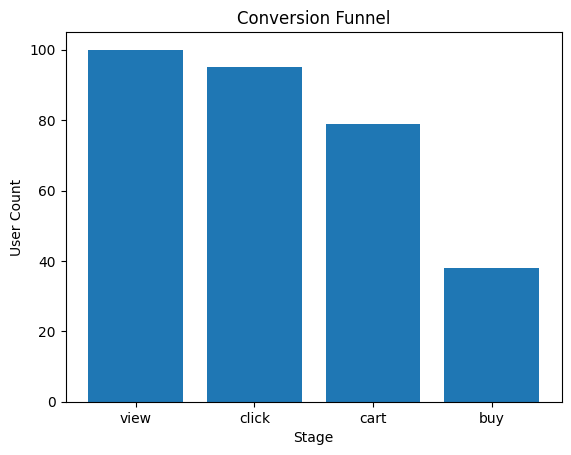

In [6]:
import matplotlib.pyplot as plt

# 1. 转化漏斗图（柱状图）
stages = ['view', 'click', 'cart', 'buy']
counts = [view_users, click_users, cart_users, buy_users]

plt.figure()
plt.bar(stages, counts)
plt.title("Conversion Funnel")
plt.xlabel("Stage")
plt.ylabel("User Count")
plt.show()

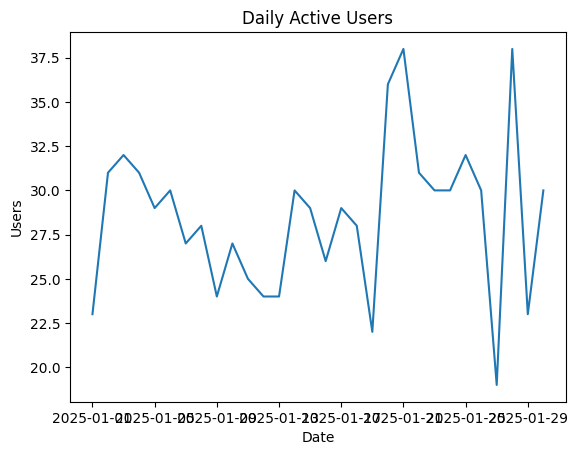

In [7]:
# 2. DAU趋势图
plt.figure()
dau.plot()
plt.title("Daily Active Users")
plt.xlabel("Date")
plt.ylabel("Users")
plt.show()

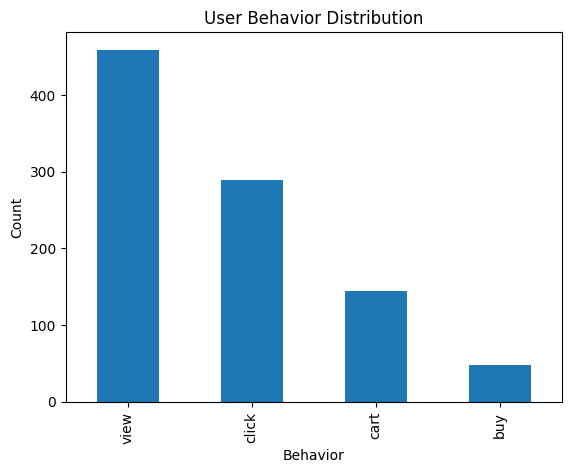

In [8]:
# 3. 行为分布图
plt.figure()
behavior_counts.plot(kind='bar')
plt.title("User Behavior Distribution")
plt.xlabel("Behavior")
plt.ylabel("Count")
plt.show()